## Import Libraries

In [1]:
# pandas to work tabular data
import pandas as pd
# numpy for numerical operations
import numpy as np
# matplotlib to make plots
import matplotlib.pyplot as plt
# tttest_ind to compare gene expression between two independent groups
from scipy.stats import ttest_ind
# PCA to reduce high dimensional data to visualize patterns between samples
from sklearn.decomposition import PCA
# StandardScaler to standardize values before PCA
from sklearn.preprocessing import StandardScaler

import os
os.makedirs("figures", exist_ok=True)
os.makedirs("results", exist_ok=True)

## Load Dataset

In [2]:
#Loads dataset that is separated by tabs
df = pd.read_csv("data/GSE296390_raw_counts_all_samples.txt", sep="\t")
# display structure of dataset
df.head()

,Unnamed: 0,NGS3280,NGS3281,NGS3282,NGS3283,NGS3284,NGS3285,NGS3286,NGS3287,NGS3288,NGS3289,NGS3290,NGS3291
0,0610005C13Rik,3,4,1,6,0,1,0,1,1,5,0,2
1,0610007P14Rik,688,763,656,591,564,533,621,462,795,658,601,713
2,0610009B22Rik,69,16,85,79,88,52,74,44,80,104,81,60
3,0610009L18Rik,44,28,34,37,36,20,22,37,57,39,26,51
4,0610009O20Rik,97,80,76,69,73,45,74,51,55,82,46,63


In [3]:
# checks table shape by returning (rows = # of genes, columns = # of samples + unnamed column)
print(df.shape)
# verify column names
print(df.columns.tolist())

(24426, 13)
['Unnamed: 0', 'NGS3280', 'NGS3281', 'NGS3282', 'NGS3283', 'NGS3284', 'NGS3285', 'NGS3286', 'NGS3287', 'NGS3288', 'NGS3289', 'NGS3290', 'NGS3291']


In [4]:
# take unnamed column
column = df.columns[0]
# convert that column into row labels (the index)
df = df.set_index(column)
# confirm table structure
df.head()

,NGS3280,NGS3281,NGS3282,NGS3283,NGS3284,NGS3285,NGS3286,NGS3287,NGS3288,NGS3289,NGS3290,NGS3291
Unnamed: 0,,,,,,,,,,,,
0610005C13Rik,3,4,1,6,0,1,0,1,1,5,0,2
0610007P14Rik,688,763,656,591,564,533,621,462,795,658,601,713
0610009B22Rik,69,16,85,79,88,52,74,44,80,104,81,60
0610009L18Rik,44,28,34,37,36,20,22,37,57,39,26,51
0610009O20Rik,97,80,76,69,73,45,74,51,55,82,46,63


In [5]:
#disease model columns
FAD_col = ["NGS3283","NGS3284","NGS3285"]
#disease model without p75NTR
FAD_KO_col = ["NGS3289","NGS3290","NGS3291"]
#combine all selected sample columns
conditions_col = FAD_col + FAD_KO_col
#subset the dataset to include only selected samples
conditions = df[conditions_col].copy()
conditions.head() # display to verify

,NGS3283,NGS3284,NGS3285,NGS3289,NGS3290,NGS3291
Unnamed: 0,,,,,,
0610005C13Rik,6,0,1,5,0,2
0610007P14Rik,591,564,533,658,601,713
0610009B22Rik,79,88,52,104,81,60
0610009L18Rik,37,36,20,39,26,51
0610009O20Rik,69,73,45,82,46,63


In [6]:
#To ensure clean analysis, convert all values into numeric and the invalid values become NaN
conditions = conditions.apply(pd.to_numeric, errors = "coerce")
#Removes rows(genes) that have missing values or non-numeric values
conditions = conditions.dropna()
conditions.head() #display to verify

,NGS3283,NGS3284,NGS3285,NGS3289,NGS3290,NGS3291
Unnamed: 0,,,,,,
0610005C13Rik,6,0,1,5,0,2
0610007P14Rik,591,564,533,658,601,713
0610009B22Rik,79,88,52,104,81,60
0610009L18Rik,37,36,20,39,26,51
0610009O20Rik,69,73,45,82,46,63


## CMP Normalization

In [7]:
#Normalize raw counts to CPM (counts per million)
CPM = conditions.div(conditions.sum(axis=0), axis=1) * 1e6
#Apply log2 transformation to CPM normalized data
log_con = np.log2(CPM + 1)
log_con.head() #display to verify

,NGS3283,NGS3284,NGS3285,NGS3289,NGS3290,NGS3291
Unnamed: 0,,,,,,
0610005C13Rik,0.421967,0.000000,0.092577,0.362655,0.000000,0.169414
0610007P14Rik,5.107088,5.170020,5.182829,5.270900,5.319873,5.505271
0610009B22Rik,2.452441,2.691838,2.152570,2.795856,2.643525,2.244293
0610009L18Rik,1.630006,1.693406,1.217515,1.691159,1.424774,2.062585
0610009O20Rik,2.294888,2.467396,1.993595,2.507656,1.993010,2.300109


## Boxplot

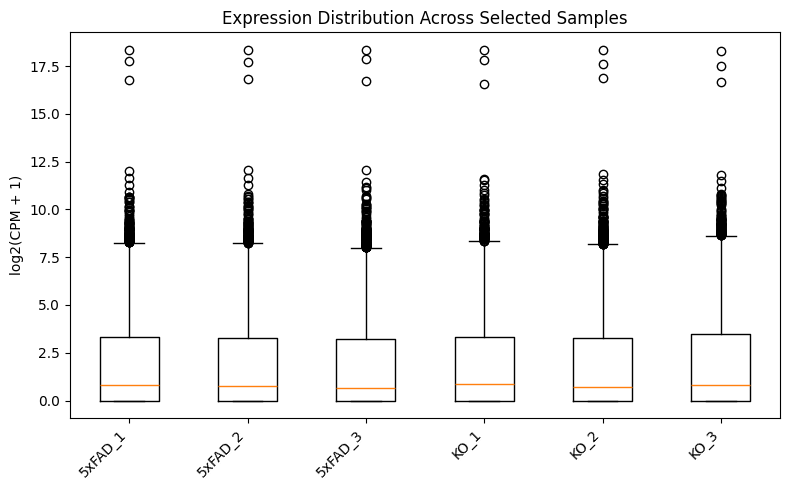

In [8]:
#Set figure size
plt.figure(figsize = (8,5))
#Sample labels
samples = ["5xFAD_1", "5xFAD_2", "5xFAD_3", "KO_1", "KO_2", "KO_3"]
#Creates one boxplot per sample
plt.boxplot([log_con[col] for col in log_con.columns], tick_labels = samples)
#Labels
plt.xticks(rotation=45, ha="right") #Rotate sample names for readability
plt.ylabel("log2(CPM + 1)")
plt.title("Expression Distribution Across Selected Samples")
plt.tight_layout() # adjust spacing so labels do not overlap
#save plot
plt.savefig("figures/boxplot_expression.png", dpi=300, bbox_inches="tight")
plt.show()

## PCA Analysis

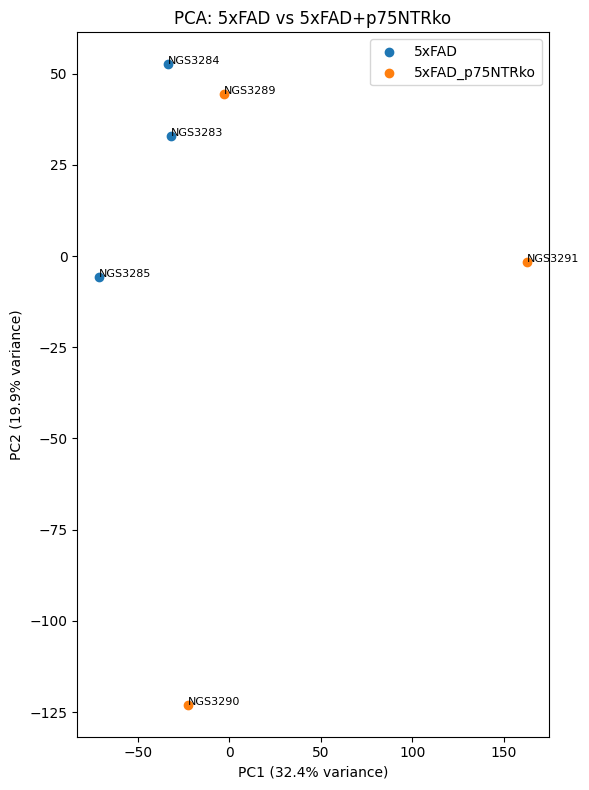

In [9]:
#Transpose data so samples are the observations and genes are the features
pca_input = log_con.T
#Standardize gene expression values
scaler = StandardScaler()
scaled = scaler.fit_transform(pca_input)

#Reduce data into 2 principal components
pca = PCA(n_components=2)
pcs = pca.fit_transform(scaled)

#Store percent variance explained by each principal component
explained = pca.explained_variance_ratio_ * 100

#Create Dataframe to store PCA results. Samples are rows and PC1 and 2 are columns
pca_df = pd.DataFrame(pcs, columns=["PC1", "PC2"], index = pca_input.index)
#Assignes each sample to one of the principle conditions to be colored separately
pca_df["group"] = ["5xFAD" if s in FAD_col else "5xFAD_p75NTRko" for s in pca_df.index]
#Create plot
plt.figure(figsize=(6,8))
#Plot each group separately
for group in ["5xFAD","5xFAD_p75NTRko"]:
    subset = pca_df[pca_df["group"] == group]
    plt.scatter(subset["PC1"], subset["PC2"], label = group)
#Add labels to each point
for sample in pca_df.index:
    plt.text(pca_df.loc[sample, "PC1"], pca_df.loc[sample, "PC2"], sample, fontsize=8)

#Label axes and title
plt.xlabel(f"PC1 ({explained[0]:.1f}% variance)")
plt.ylabel(f"PC2 ({explained[1]:.1f}% variance)")
plt.title("PCA: 5xFAD vs 5xFAD+p75NTRko")

#Display plot and legend
plt.legend()
plt.tight_layout()
plt.savefig("figures/pca_plot.png", dpi=300, bbox_inches="tight")
plt.show()

## Results

In [10]:
results = []
# Remove low-expression genes. Keep genes that have sufficient expression in at least one condition.
#Filter: Keep gene if avg expression is greater than two in either group
filtered = log_con[(log_con[FAD_col].mean(axis=1) > 2) | (log_con[FAD_KO_col].mean(axis=1) > 2)]

#Loop through to get Mean, fold change, t-test and store results
for gene in filtered.index:
    #Get expression values for this gene in both conditions
    FAD_vales = filtered.loc[gene, FAD_col].values
    FAD_KO_values = filtered.loc[gene, FAD_KO_col].values
    #Mean for each group
    FAD_mean = np.mean(FAD_vales)
    FAD_KO_mean = np.mean(FAD_KO_values)
    #log2 fold change: positive means higher in KO. negative means higher in 5xFAD
    log2_fc = FAD_KO_mean - FAD_mean
    #t-test to compare expression between two groups
    stat, pval = ttest_ind(FAD_vales, FAD_KO_values, equal_var = False)
    #store results
    results.append([gene, FAD_mean, FAD_KO_mean, log2_fc, pval])

#Convert results into DataFrame
results_df = pd.DataFrame(
    results,
    columns = ["gene", "FAD_mean", "FAD_KO_mean", "log2_fold_change", "p_value"]
)

#p-values for plotting
#Replace 0 p-values to avoid log(0)
results_df["p_value"] = results_df["p_value"].replace(0, 1e-300)
#Convert p-values to -log10 for volcano plot
results_df["neg_log10_p"] = -np.log10(results_df["p_value"])

#Sort genes by significance
results_df = results_df.sort_values("p_value")
results_df.to_csv("results/differential_expression_results.csv", index=False)
results_df.head(20) #display top significant genes

,gene,FAD_mean,FAD_KO_mean,log2_fold_change,p_value,neg_log10_p
2164,Ddx3y,5.338282,0.398450,-4.939831,0.000008,5.108104
8880,Uty,3.328082,0.030193,-3.297889,0.000053,4.279714
9066,Xist,0.774324,7.108386,6.334062,0.000056,4.254633
4574,Mbtd1,5.559031,4.573968,-0.985063,0.000113,3.946466
2307,Dnajc18,4.561514,4.779761,0.218248,0.000165,3.783565
1405,Ccnt2,3.630732,3.309276,-0.321456,0.000235,3.628972
4081,Kdm5d,2.199563,0.030193,-2.169370,0.000428,3.368147
2540,Eif2s3y,3.236410,0.029064,-3.207346,0.000483,3.316110
6518,Ranbp6,3.765237,3.932757,0.167520,0.000930,3.031418
4613,Med1,5.096297,5.855025,0.758729,0.001025,2.989486


## Volcano Plot

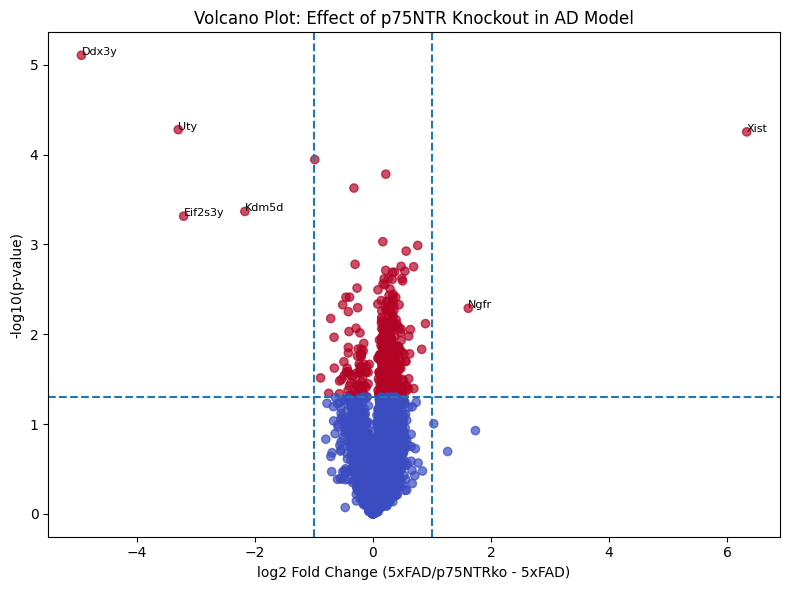

In [11]:
plt.figure(figsize=(8,6)) #create figure
#Define significant genes using p-value threshold
sig = results_df["p_value"] < 0.05

#Plot all genes using log2 fold change and -log10(p-value)
#Color indicates whether gene is significant
plt.scatter(
    results_df["log2_fold_change"],
    results_df["neg_log10_p"],
    c=sig,
    cmap="coolwarm",
    alpha=0.7
)

# Add threshold lines for significance and fold change
plt.axhline(-np.log10(0.05), linestyle="--")
plt.axvline(1, linestyle="--")
plt.axvline(-1, linestyle="--")
# Select top genes with strong significance and large effect size
top_genes = results_df[(results_df["p_value"] < 0.01) & (abs(results_df["log2_fold_change"]) > 1)].head(10)

#Gene labels to top points
for _, row in top_genes.iterrows():
    plt.text(
        row["log2_fold_change"],
        row["neg_log10_p"],
        row["gene"],
        fontsize=8)

#Label axes and title
plt.xlabel("log2 Fold Change (5xFAD/p75NTRko - 5xFAD)")
plt.ylabel("-log10(p-value)")
plt.title("Volcano Plot: Effect of p75NTR Knockout in AD Model")
#Layout and Display
plt.tight_layout()
plt.savefig("figures/volcano_plot.png", dpi=300, bbox_inches="tight")
plt.show()

## Heatmap

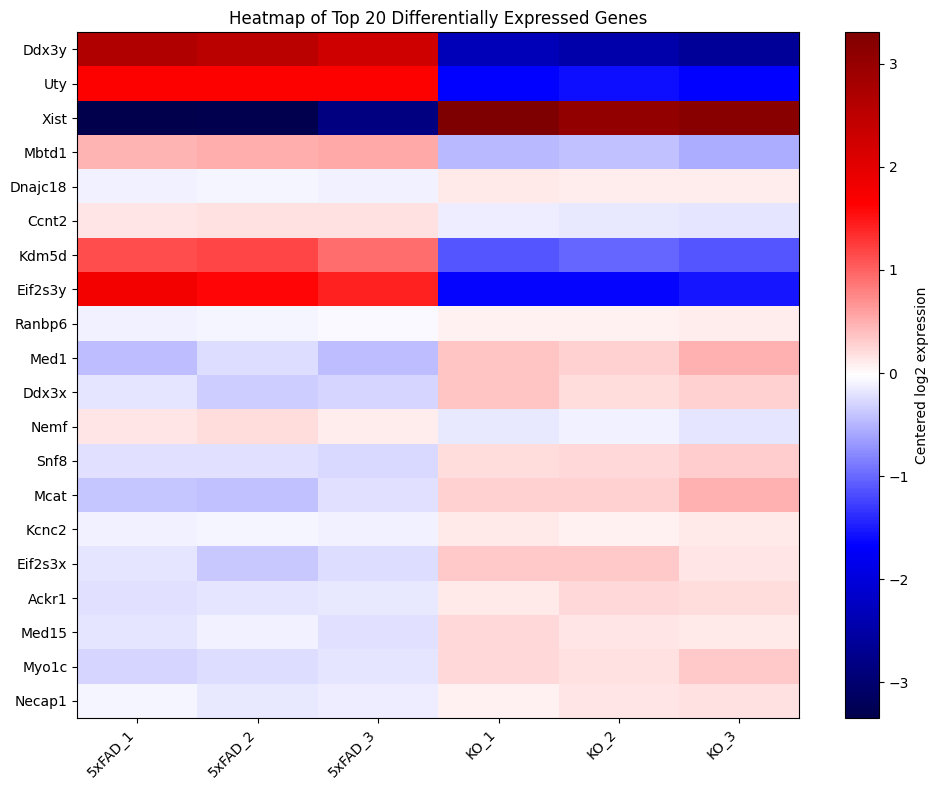

In [12]:
#Select top 20 most significant genes
top20_genes = results_df.head(20)["gene"]
#Get expression data for these genes
heatmap_data = log_con.loc[top20_genes]

#Center expression values per gene. Subtract mean across samples
heatmap_scaled = heatmap_data.sub(heatmap_data.mean(axis=1), axis=0)

#Rename columns
heatmap_scaled.columns = [
    "5xFAD_1", "5xFAD_2", "5xFAD_3",
    "KO_1", "KO_2", "KO_3"
]

#Generate heat map
plt.figure(figsize=(10, 8))
plt.imshow(heatmap_scaled, aspect="auto", cmap="seismic")
plt.colorbar(label="Centered log2 expression")
plt.yticks(range(len(top20_genes)), top20_genes)
plt.xticks(range(len(heatmap_scaled.columns)), heatmap_scaled.columns, rotation=45, ha="right")
plt.title("Heatmap of Top 20 Differentially Expressed Genes")
plt.tight_layout()
plt.savefig("figures/heatmap_top20.png", dpi=300, bbox_inches="tight")
plt.show()